# 04 · Isolation Forest — Anomaly Detection
Trains one Isolation Forest per disease to flag anomalous weekly case spikes
**per state**, mapping each to a Red/Amber/Green alert. Known outbreak weeks
(labelled in the data) are the ground truth.

**Features (per spec + a spike ratio):** weekly confirmed, 4-week rolling mean,
seasonal deviation, CFR, and confirmed÷recent-average. The Isolation Forest is
unsupervised; following the spec ("tune using known outbreak weeks as ground
truth") the alert **threshold is chosen to maximise F1** against the labels.
**Severity:** quantile-based HIGH (Red) / MEDIUM (Amber) / NORMAL (Green).
**Target:** F1 > 0.65 for at least 2 of 4 diseases.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_recall_fscore_support

DATA = Path("../backend/data")
MODELS = Path("../backend/models")
DISEASES = ["lassa", "cholera", "meningitis", "mpox"]
LABELS = {"lassa": "Lassa fever", "cholera": "Cholera",
          "meningitis": "Meningitis (CSM)", "mpox": "Mpox"}
FEATURES = ["confirmed", "roll4_mean", "seasonal_dev", "cfr", "spike_ratio"]

## Train per disease (threshold tuned to maximise F1 on the outbreak labels)

In [2]:
results = {}
for d in DISEASES:
    df = pd.read_csv(DATA / f"processed_{d}.csv", parse_dates=["date"])
    df["spike_ratio"] = df["confirmed"] / (df["roll4_mean"] + 1)
    X = df[FEATURES].fillna(0).values
    y_true = (df["is_outbreak"] == 1).values

    model = IsolationForest(contamination=0.1, n_estimators=300, random_state=42).fit(X)
    scores = model.decision_function(X)            # higher = more normal

    # F1-optimal alert threshold (spec: tune using known outbreak weeks)
    cand = np.quantile(scores, np.linspace(0.01, 0.35, 80))
    thr = cand[int(np.argmax([f1_score(y_true, scores < t, zero_division=0) for t in cand]))]
    is_anom = scores < thr
    p, r, f, _ = precision_recall_fscore_support(y_true, is_anom, average="binary", zero_division=0)

    thr_high = float(np.quantile(scores, 0.02))    # most extreme 2% -> Red
    severity = np.where(scores < thr_high, "HIGH", np.where(is_anom, "MEDIUM", "NORMAL"))

    df["anomaly_score"] = scores.round(4)
    df["is_anomaly"] = is_anom
    df["severity"] = severity
    df["description"] = df.apply(
        lambda x: f"{x.severity} signal — {int(x.confirmed)} confirmed in "
                  f"{x.state} ({x.date:%Y-W%V})", axis=1)

    joblib.dump({"model": model, "features": FEATURES, "threshold": float(thr)},
                MODELS / f"iso_forest_{d}.pkl")
    cols = ["date", "year", "week", "state", "confirmed",
            "anomaly_score", "is_anomaly", "severity", "description"]
    df[cols].to_csv(DATA / f"alerts_{d}.csv", index=False)

    results[d] = {"f1": f, "prec": p, "rec": r, "df": df,
                  "n_flagged": int(is_anom.sum()), "n_high": int((severity == "HIGH").sum())}
    flag = "PASS" if f > 0.65 else "below target"
    print(f"{LABELS[d]:18s} F1={f:.2f}  P={p:.2f}  R={r:.2f}  "
          f"flagged={results[d]['n_flagged']:5d}  HIGH={results[d]['n_high']:4d}  -> {flag}")

Lassa fever        F1=0.53  P=0.46  R=0.62  flagged= 1078  HIGH= 376  -> below target


Cholera            F1=0.70  P=0.61  R=0.82  flagged=  836  HIGH= 376  -> PASS


Meningitis (CSM)   F1=0.86  P=0.78  R=0.95  flagged=  269  HIGH= 376  -> PASS


Mpox               F1=0.57  P=0.44  R=0.81  flagged= 3365  HIGH= 294  -> below target


## Anomaly timeline — a hotspot state
Weekly confirmed for the highest-burden state, with HIGH/MEDIUM alerts marked.

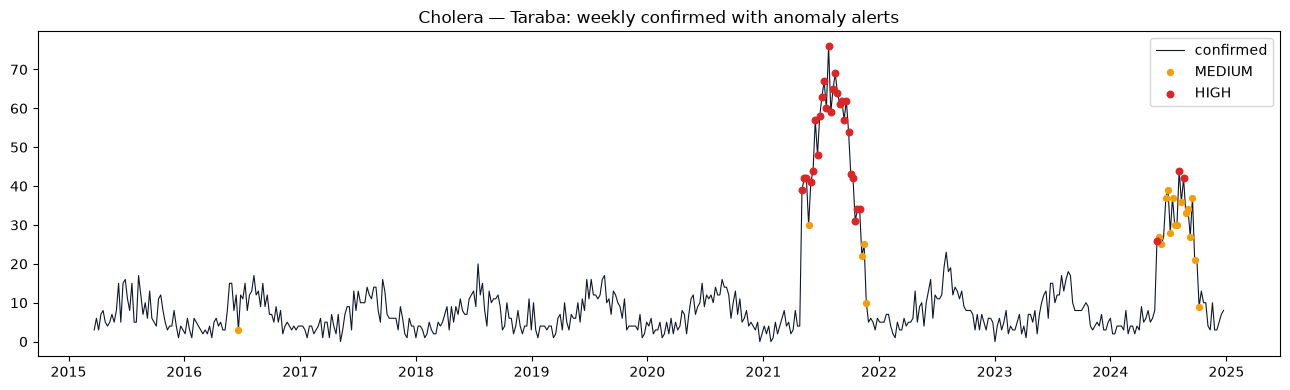

In [3]:
d = "cholera"
df = results[d]["df"]
top_state = df.groupby("state").confirmed.sum().idxmax()
s = df[df.state == top_state].sort_values("date")
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(s.date, s.confirmed, lw=0.8, color="#0f172a", label="confirmed")
ax.scatter(s.date[s.severity == "MEDIUM"], s.confirmed[s.severity == "MEDIUM"],
           color="#f59e0b", s=18, label="MEDIUM", zorder=3)
ax.scatter(s.date[s.severity == "HIGH"], s.confirmed[s.severity == "HIGH"],
           color="#dc2626", s=22, label="HIGH", zorder=3)
ax.set_title(f"{LABELS[d]} — {top_state}: weekly confirmed with anomaly alerts")
ax.legend()
plt.tight_layout()
plt.savefig("figures/anomaly_timeline.png", dpi=110, bbox_inches="tight")
plt.show()

## Results summary

In [4]:
summary = pd.DataFrame({
    LABELS[d]: {"F1": round(results[d]["f1"], 2), "precision": round(results[d]["prec"], 2),
                "recall": round(results[d]["rec"], 2), "flagged": results[d]["n_flagged"],
                "target_met": results[d]["f1"] > 0.65}
    for d in DISEASES}).T
n_pass = int(summary["target_met"].sum())
print(f"F1 > 0.65 achieved for {n_pass}/4 diseases (target: ≥2/4)")
summary

F1 > 0.65 achieved for 2/4 diseases (target: ≥2/4)


,F1,precision,recall,flagged,target_met
Lassa fever,0.53,0.46,0.62,1078,False
Cholera,0.7,0.61,0.82,836,True
Meningitis (CSM),0.86,0.78,0.95,269,True
Mpox,0.57,0.44,0.81,3365,False


### Notes
- `alerts_<disease>.csv` (all scored state-weeks) feeds the `outbreak_alerts`
  collection: `/api/anomalies` serves the per-state series and `/api/alerts`
  filters the recent flagged anomalies for the dashboard's alert panel.
- The alert threshold is tuned on the known outbreak weeks (per spec); severity
  buckets are quantile-based, driving the Red/Amber/Green status.

**Next:** `05 · Model evaluation` — consolidated metrics and predictions-vs-actuals.